# Edges

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
from skimage import img_as_float
from skimage.filters import sobel, sobel_h, sobel_v, difference_of_gaussians
from skimage.filters.rank import mean
from skimage.feature import canny
from skimage.util import random_noise

plt.style.use('../../src/bip.mplstyle')
plt.rcParams['image.cmap'] = 'gray'

## Profiles

float64


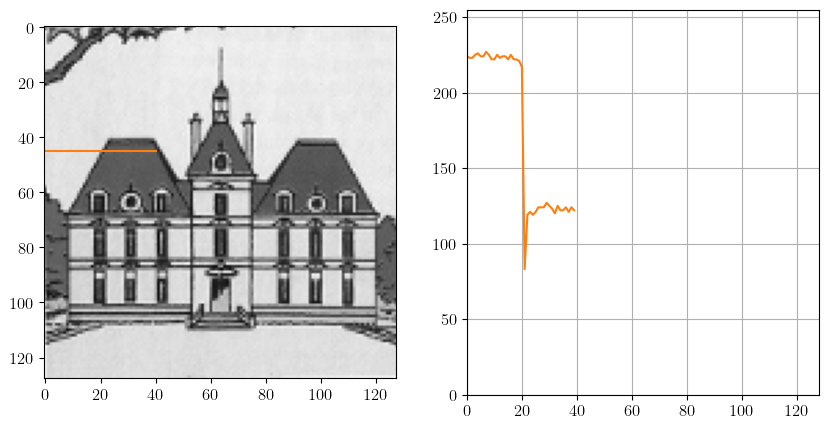

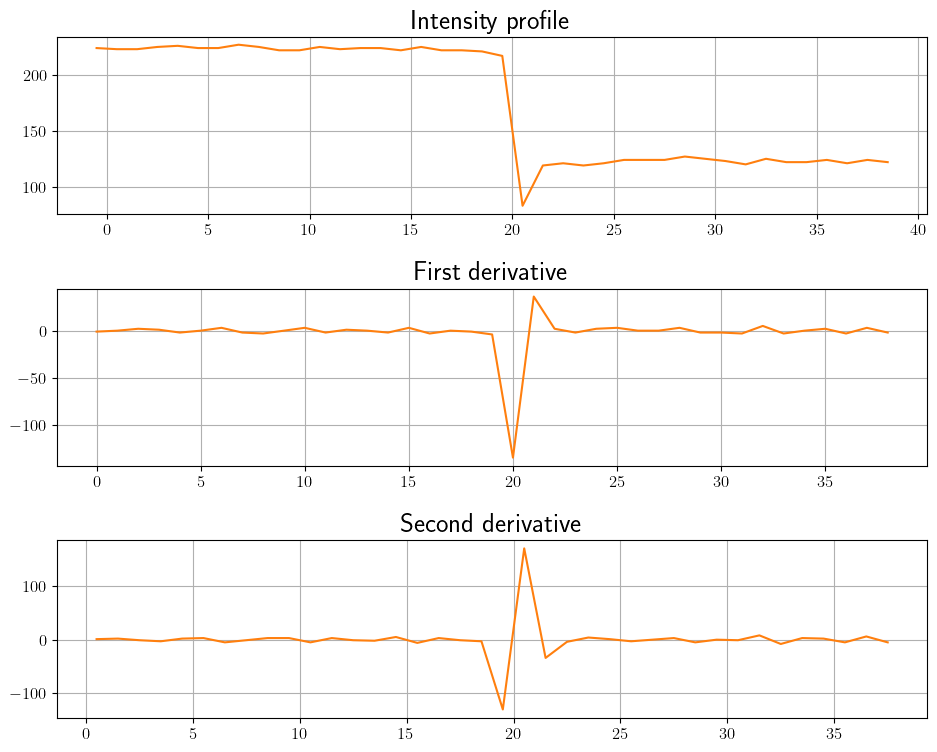

In [2]:
# Couleur du profil
clr = "tab:orange"

# Chargement
img = io.imread('moulinsart.png') * 1.
print(img.dtype)
N, _ = img.shape

# Profil et ses dérivées
x1, x2 = 0, 40
y = 45
profile = img[y, x1:x2]
der1 = np.diff(profile)
der2 = np.diff(der1)
c = x1 + np.argmin(der1)

# Affichage du profil
fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(img)
axs[0].plot([x1, x2], [y, y], color=clr)
axs[1].plot(range(x1, x2), profile, color=clr)
axs[1].set_xlim([0, N])
axs[1].set_ylim([0, 255])
axs[1].grid()
plt.savefig('edges-profile.svg', bbox_inches='tight')
plt.show()

# Affichage des dérivées
# Les décalages de .5 sur les abscisses permettent de centrer les dérivées
fig, axs = plt.subplots(3, 1, figsize=(10,8))
fig.tight_layout(pad=2.0)
axs[0].plot(np.arange(x1, x2)-.5, profile, color=clr)
axs[0].set_title('Intensity profile')
axs[1].plot(np.arange(x1, x2-1), der1, color=clr)
axs[1].set_title('First derivative')
axs[2].plot(np.arange(x1, x2-2)+.5, der2, color=clr)
axs[2].set_title('Second derivative')
for i in range(3):
    axs[i].grid()
plt.savefig('edges-derivatives.svg', bbox_inches='tight')
plt.show()

## Sobel filter

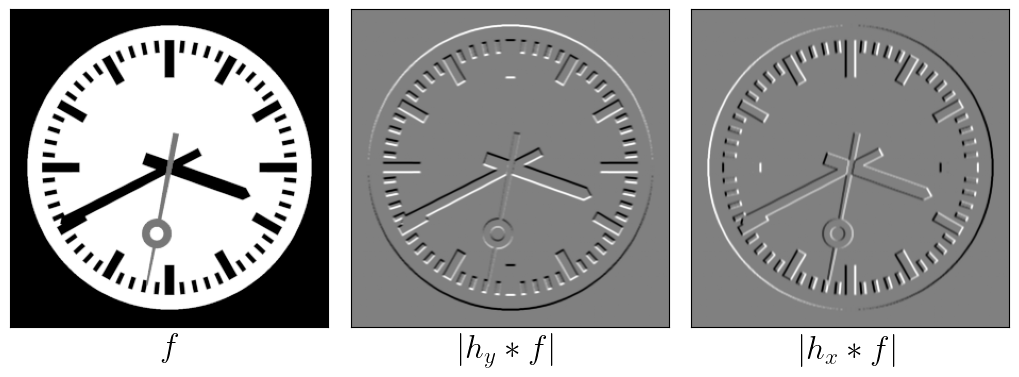

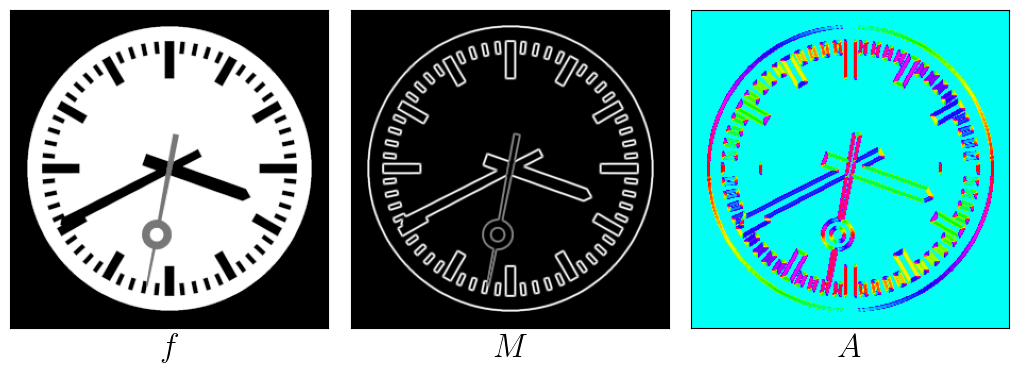

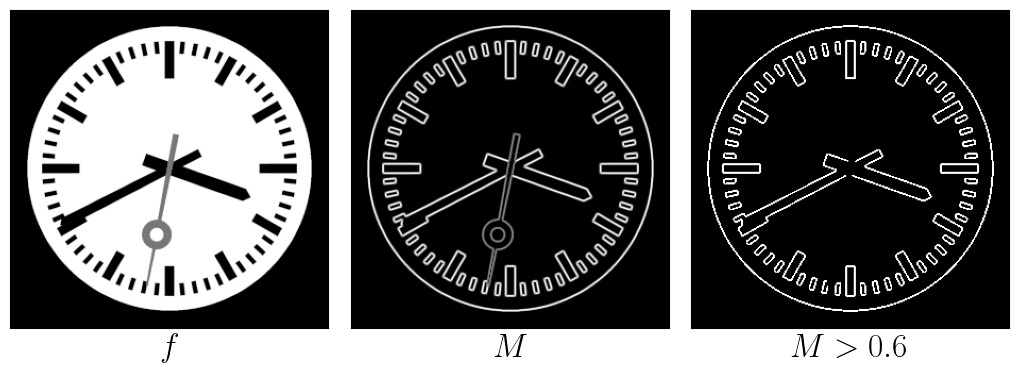

In [3]:
img = io.imread('station-clock.png')

h = sobel_h(img)
v = sobel_v(img)

M = np.sqrt(h**2 + v**2)
A = np.arctan(v/(h+1e-12))

fig, axs = plt.subplots(1, 3, figsize=(10,5))
fig.tight_layout(pad=-1)
axs[0].imshow(img, cmap='gray')
axs[0].set_xlabel('$f$', fontsize=24)
axs[1].imshow(h, cmap='gray')
axs[1].set_xlabel('$|h_y*f|$', fontsize=24)
axs[2].imshow(v, cmap='gray')
axs[2].set_xlabel('$|h_x*f|$', fontsize=24)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("sobel-h-v.svg", bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(10,5))
fig.tight_layout(pad=-1)
axs[0].imshow(img, cmap='gray')
axs[0].set_xlabel('$f$', fontsize=24)
axs[1].imshow(M, cmap='gray')
axs[1].set_xlabel('$M$', fontsize=24)
axs[2].imshow(A, cmap='hsv')
axs[2].set_xlabel('$A$', fontsize=24)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("sobel-magnitude-angle.svg", bbox_inches='tight')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(10,5))
fig.tight_layout(pad=-1)
axs[0].imshow(img, cmap='gray')
axs[0].set_xlabel('$f$', fontsize=24)
axs[1].imshow(M, cmap='gray')
axs[1].set_xlabel('$M$', fontsize=24)
axs[2].imshow(M>.6, cmap='gray')
axs[2].set_xlabel('$M>0.6$', fontsize=24)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("sobel-magnitude-threshold.svg", bbox_inches='tight')
plt.show()

## Noise impact

0.09234484611521362
1.0


/home/vinc/.miniconda3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


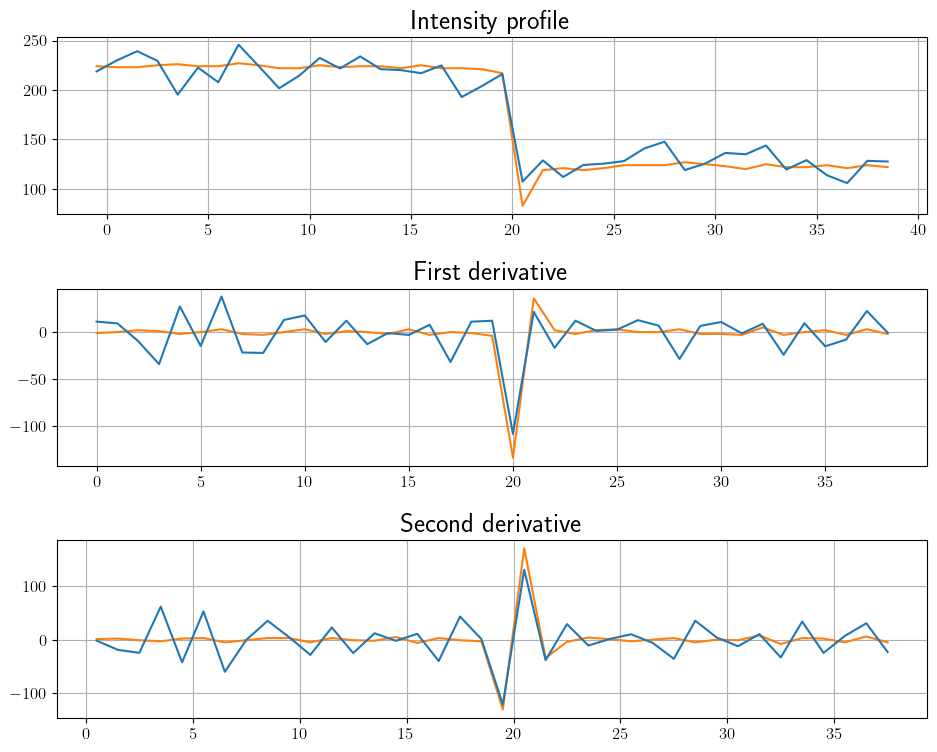

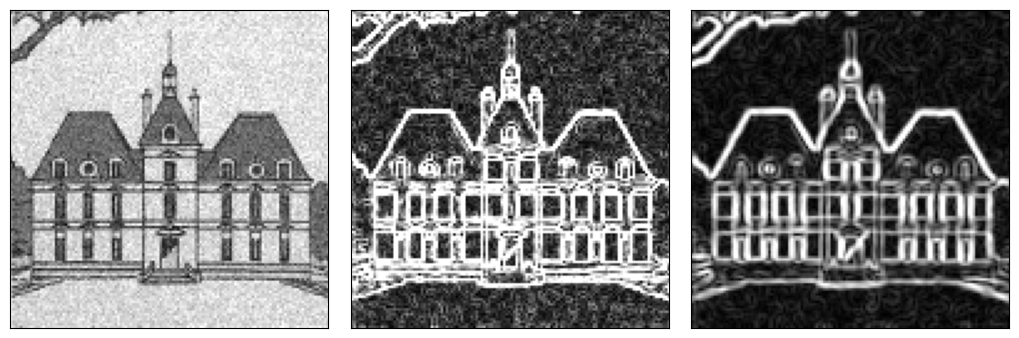

In [4]:
clr = "tab:orange"

# Image
img = io.imread('moulinsart.png')
noisy = random_noise(img, mode='gaussian', clip=True, var=.003)

# Profil et ses dérivées
profile_noisy = noisy[y, x1:x2]*255
der1_noisy = np.diff(profile_noisy)
der2_noisy = np.diff(der1_noisy)
c = x1 + np.argmin(der1_noisy)

# Sobel
img_s = sobel(img)
noisy_s = sobel(noisy)
noisy = img_as_float(noisy)
print(noisy.min())
print(noisy.max())
denoised = mean(img_as_float(noisy), footprint=np.ones((3,3)))
denoised_s = sobel(denoised)

# Affichage des dérivées
# Les décalages de .5 sur les abscisses permettent de centrer les dérivées
fig, axs = plt.subplots(3, 1, figsize=(10,8))
fig.tight_layout(pad=2.0)
axs[0].plot(np.arange(x1, x2)-.5, profile, color=clr)
axs[0].plot(np.arange(x1, x2)-.5, profile_noisy, color='tab:blue')
axs[0].set_title('Intensity profile')
axs[1].plot(np.arange(x1, x2-1), der1, color=clr)
axs[1].plot(np.arange(x1, x2-1), der1_noisy, color='tab:blue')
axs[1].set_title('First derivative')
axs[2].plot(np.arange(x1, x2-2)+.5, der2, color=clr)
axs[2].plot(np.arange(x1, x2-2)+.5, der2_noisy, color='tab:blue')
axs[2].set_title('Second derivative')
for i in range(3):
    axs[i].grid()
plt.savefig('edges-derivatives-noise.svg', bbox_inches='tight')
plt.show()

# Détection de contours
t = .08
fig, axs = plt.subplots(1, 3, figsize=(10,5))
fig.tight_layout(pad=-1)
axs[0].imshow(noisy, "gray")
axs[1].imshow(noisy_s, "gray", vmax=.2)
axs[2].imshow(denoised_s, "gray", vmax=.2)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig('edges-sobel-noise.svg', bbox_inches='tight')
plt.show()

## LoG

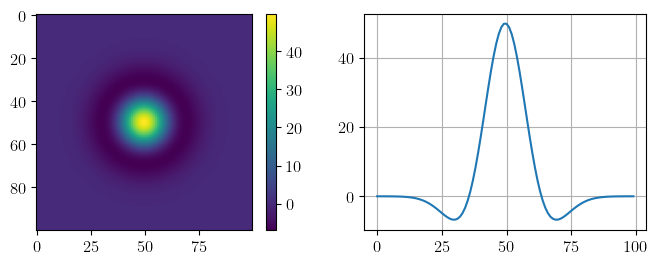

In [5]:
N = 100
n = np.linspace(-1, 1, N)
x, y = np.meshgrid(n,n)
sigma = .2
LoG = - (x**2+y**2-2*sigma**2) / sigma**4 * np.exp(-(x**2+y**2)/(2*sigma**2))

fig, axs = plt.subplots(1, 2, figsize=(8,2.8))
tmp = axs[0].imshow(LoG, cmap="viridis")
fig.colorbar(tmp, ax=axs[0])
axs[1].plot(LoG[N//2,:])
axs[1].grid()
plt.savefig('log.svg', bbox_inches='tight')
plt.show()

## Marr-Hildreth

In [6]:
def marr_hildreth(img, low_sigma):

    LoG = difference_of_gaussians(img, low_sigma=low_sigma)
    
    # Zero crossing (from https://github.com/adl1995/edge-detectors/blob/master/marr-hildreth-edge.py)
    mh = np.zeros(LoG.shape)
    for i in range(LoG.shape[0]-1):
        for j in range(LoG.shape[1]-1):
            if LoG[i][j] == 0:
                if (LoG[i][j-1] < 0 and LoG[i][j+1] > 0) \
                or (LoG[i][j-1] < 0 and LoG[i][j+1] < 0) \
                or (LoG[i-1][j] < 0 and LoG[i+1][j] > 0) \
                or (LoG[i-1][j] > 0 and LoG[i+1][j] < 0):
                    mh[i][j] = 1
            if LoG[i][j] < 0:
                if (LoG[i][j-1] > 0) \
                or (LoG[i][j+1] > 0) \
                or (LoG[i-1][j] > 0) \
                or (LoG[i+1][j] > 0):
                    mh[i][j] = 1
                    
    return mh, LoG

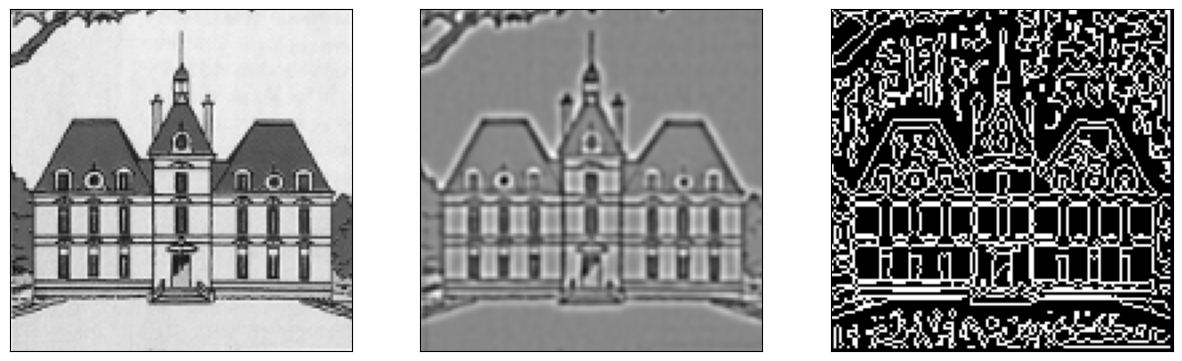

In [7]:
img = io.imread('moulinsart.png')
if len(img.shape) > 2:
    img = rgb2gray(img)

mh, LoG = marr_hildreth(img, low_sigma=1)

fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[0].imshow(img, cmap='gray')
axs[1].imshow(LoG, cmap='gray')
axs[2].imshow(mh, cmap='gray')
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig('moulinsart-marr-hildreth.svg', bbox_inches='tight')
plt.show()

## Canny

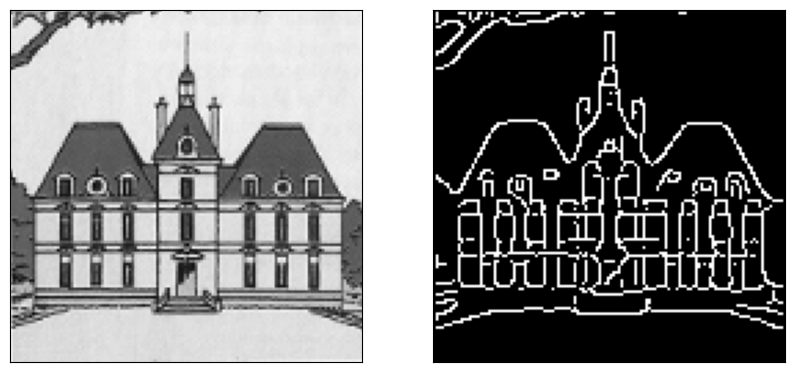

In [8]:
img = io.imread('moulinsart.png')

res = canny(img, sigma=1.5)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(img, cmap='gray')
axs[1].imshow(res, cmap='gray')
for i in range(2):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig('moulinsart-canny.svg', bbox_inches='tight')
plt.show()

## Comparison

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\ '
<>:27: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1015848/680704212.py:20: SyntaxWarning: invalid escape sequence '\s'
  axs[1,0].set_title(f'Marr-Hildreth\n($\sigma={sig}$)')
/tmp/ipykernel_1015848/680704212.py:27: SyntaxWarning: invalid escape sequence '\s'
  axs[1,1].set_title(f'Canny\n($\sigma={sig},\ T_\mathrm{{low}}={Tlow},\ T_\mathrm{{high}}={Thigh}$)')
/tmp/ipykernel_1015848/680704212.py:27: SyntaxWarning: invalid escape sequence '\ '
  axs[1,1].set_title(f'Canny\n($\sigma={sig},\ T_\mathrm{{low}}={Tlow},\ T_\mathrm{{high}}={Thigh}$)')
/tmp/ipykernel_1015848/680704212.py:27: SyntaxWarning: invalid escape sequenc

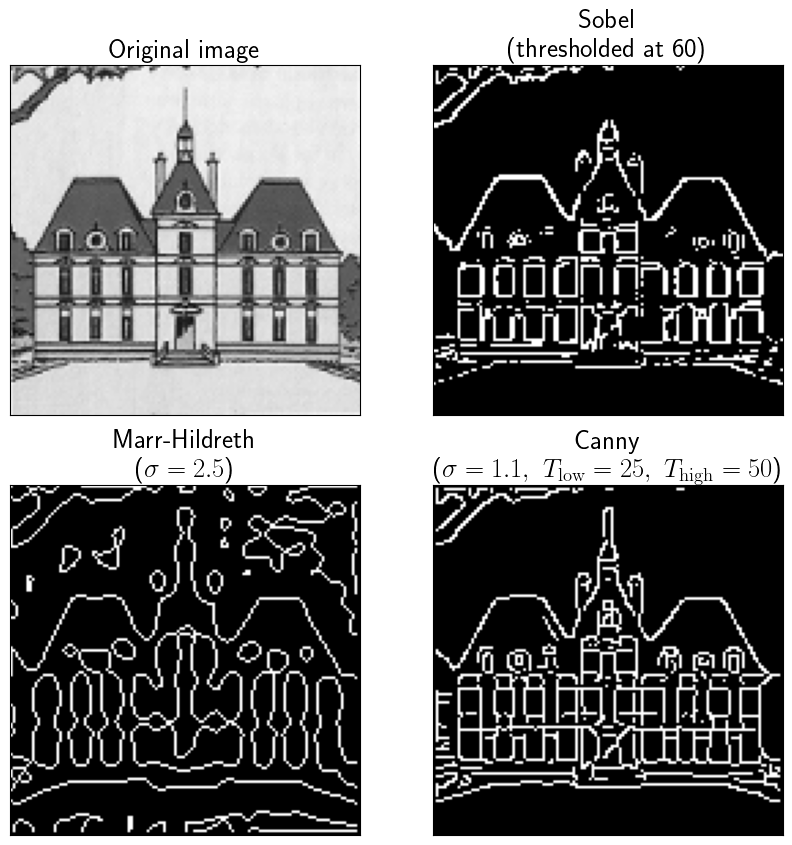

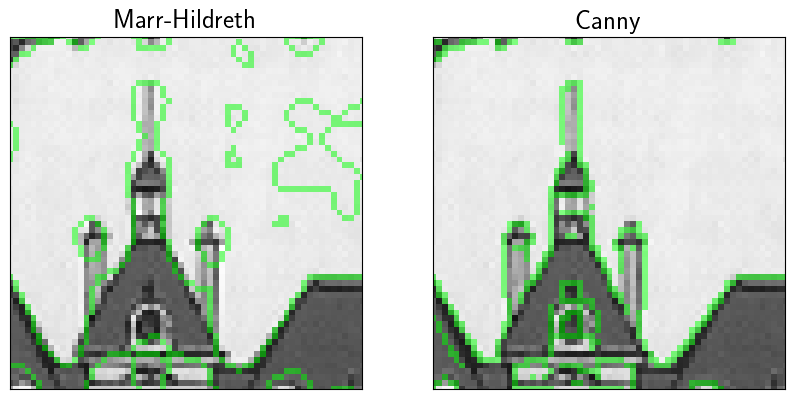

In [12]:
# Image
img = io.imread('moulinsart.png')

fig, axs = plt.subplots(2, 2, figsize=(10,10))

# Original image
axs[0,0].imshow(img, cmap='gray')
axs[0,0].set_title('Original image')

# Sobel
T = 60
res_sobel = sobel(img) * 255
axs[0,1].imshow(res_sobel>T, cmap='gray')
axs[0,1].set_title(f'Sobel\n(thresholded at {T})')

# Marr-Hildreth
sig = 2.5
res_mh, _ = marr_hildreth(img, low_sigma=sig)
axs[1,0].imshow(res_mh, cmap='gray')
axs[1,0].set_title(f'Marr-Hildreth\n($\sigma={sig}$)')

# Canny
sig = 1.1
Tlow, Thigh = 25, 50
res_canny = canny(img, sigma=sig, low_threshold=Tlow, high_threshold=Thigh)
axs[1,1].imshow(res_canny, cmap='gray')
axs[1,1].set_title(f'Canny\n($\sigma={sig},\ T_\mathrm{{low}}={Tlow},\ T_\mathrm{{high}}={Thigh}$)')

# Display
for i in range(2):
    for j in range(2):
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
plt.savefig('sobel-marr-hildreth-canny.svg', bbox_inches='tight')
plt.show()

# Zoom
from matplotlib.colors import ListedColormap
clr = np.array([
    [0, 0, 0, 0],
    [0, 1, 0, .5],
])

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].imshow(img, cmap='gray')
axs[0].imshow(res_mh, cmap=ListedColormap(clr))
axs[0].set_title(f'Marr-Hildreth')
axs[1].imshow(img, cmap='gray')
axs[1].imshow(res_canny, cmap=ListedColormap(clr))
axs[1].set_title(f'Canny')
for i in range(2):
    axs[i].set_xlim([40, 100])
    axs[i].set_ylim([60, 0])
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig('marr-hildreth-canny.svg', bbox_inches='tight')
plt.show()